# Eksperiment 2B – uticaj augmentacije manjinskih klasa

Ovaj notebook dokumentuje naknadni eksperiment kojim je provereno da li **train-only augmentacija** manjinskih klasa može da poboljša generalizaciju najboljeg modela iz Eksperimenta 2.

U osnovnom eksperimentu najbolju validation vrednost ostvarila je kombinacija **Inception-ResNet-v2 + XGBoost**. Zbog toga je u ovom eksperimentu zadržana ista arhitektura, dok je promenjen samo trening skup. Na taj način se uticaj augmentacije posmatra odvojeno od uticaja izbora modela.

> Eksperiment 2B je naknadna analiza. Isti test skup je ranije korišćen za finalnu evaluaciju Eksperimenta 2, pa rezultat nije nova potpuno nezavisna potvrda modela.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

from src.run_augmented_feature_extraction import augment_image

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

BASELINE_DIRECTORY = Path("data/results/experiment_2_multiclass")
RESULT_DIRECTORY = Path("data/results/experiment_2b_augmentation")

with (RESULT_DIRECTORY / "augmentation_report.json").open(encoding="utf-8") as file:
    augmentation_report = json.load(file)

with (RESULT_DIRECTORY / "xgboost_augmented_validation.json").open(encoding="utf-8") as file:
    validation_result = json.load(file)

with (RESULT_DIRECTORY / "final_test_results.json").open(encoding="utf-8") as file:
    final_result = json.load(file)

augmentation_metadata = pd.read_csv(
    RESULT_DIRECTORY / "augmentation_metadata.csv"
)
validation_comparison = pd.read_csv(
    RESULT_DIRECTORY / "validation_augmentation_comparison.csv"
)
test_comparison = pd.read_csv(
    RESULT_DIRECTORY / "test_experiment_comparison.csv"
)
class_f1_comparison = pd.read_csv(
    RESULT_DIRECTORY / "test_class_f1_comparison.csv"
)
classification_report = pd.read_csv(
    RESULT_DIRECTORY / "test_classification_report.csv",
    index_col=0,
)
confusion_counts = pd.read_csv(
    RESULT_DIRECTORY / "test_confusion_matrix_counts.csv",
    index_col=0,
)
confusion_normalized = pd.read_csv(
    RESULT_DIRECTORY / "test_confusion_matrix_normalized.csv",
    index_col=0,
)
test_predictions = pd.read_csv(
    RESULT_DIRECTORY / "test_predictions.csv"
)

CLASS_ORDER = ["abscission", "bulge", "corrosion", "crack", "leakage"]
COLORS = {
    "Eksperiment 2": "#4C78A8",
    "Eksperiment 2B – augmentacija": "#E45756",
}

/home/dareloq/venvs/ml/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Eksperimentalno pitanje

Početni trening skup bio je izrazito nebalansiran: `crack` je imao 3.438 slika, dok je `bulge` imao samo 600. Profesorov predlog o augmentaciji ispitan je sledećom hipotezom:

> Blage transformacije manjinskih klasa mogu povećati njihovu raznovrsnost i smanjiti validation–test razliku bez menjanja validation i test skupova.

Augmentirane su klase `bulge`, `corrosion` i `leakage` do 2.627 trening primera po klasi, koliko je imala druga najveća klasa `abscission`. Klasa `crack` nije smanjivana, jer undersampling nije odgovarajući izbor za ovaj skup.

,Originalni train,Novi augmentirani prikazi,Train posle augmentacije
abscission,2627,0,2627
bulge,600,2027,2627
corrosion,1309,1318,2627
crack,3438,0,3438
leakage,1556,1071,2627


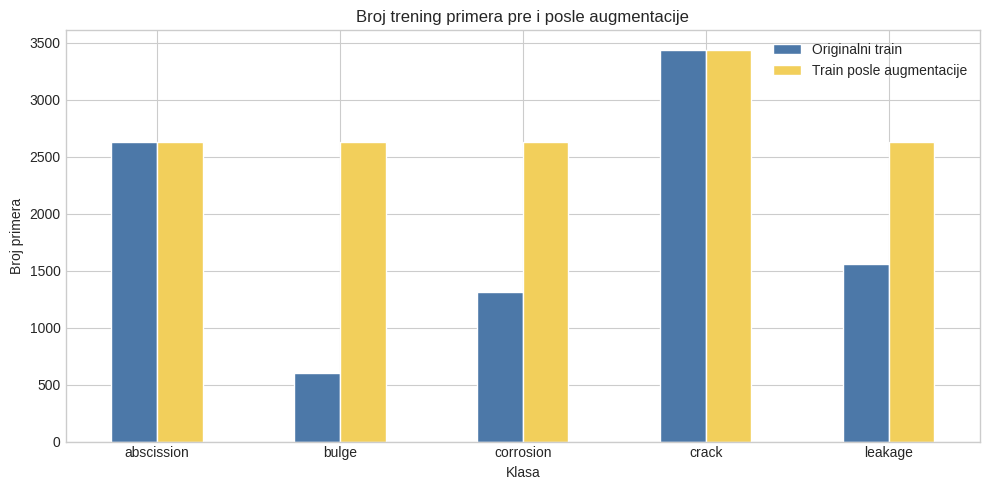

In [2]:
original_counts = pd.Series(
    augmentation_report["original_train_counts"],
    name="Originalni train",
).reindex(CLASS_ORDER)
final_counts = pd.Series(
    augmentation_report["final_train_counts"],
    name="Train posle augmentacije",
).reindex(CLASS_ORDER)
added_counts = pd.Series(
    augmentation_report["augmentation_counts"],
    name="Novi augmentirani prikazi",
).reindex(CLASS_ORDER, fill_value=0)

class_distribution = pd.concat(
    [original_counts, added_counts, final_counts],
    axis=1,
).astype(int)

display(class_distribution)

axis = class_distribution[["Originalni train", "Train posle augmentacije"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C78A8", "#F2CF5B"],
    edgecolor="white",
)
axis.set_title("Broj trening primera pre i posle augmentacije")
axis.set_xlabel("Klasa")
axis.set_ylabel("Broj primera")
axis.tick_params(axis="x", rotation=0)
axis.legend(frameon=False)
plt.tight_layout()
plt.show()

Ukupno je generisano **4.416** novih prikaza: 2.027 za `bulge`, 1.318 za `corrosion` i 1.071 za `leakage`. Trening skup je povećan sa 9.530 na 13.946 primera. Originalne slike nisu uklonjene.

## 2. Transformacije

Korišćene su blage transformacije koje čuvaju semantiku defekta:

- horizontalno preslikavanje sa verovatnoćom 0,5;
- rotacija od −10° do +10°;
- faktor svetline od 0,90 do 1,10;
- faktor kontrasta od 0,90 do 1,10;
- faktor zasićenosti od 0,90 do 1,10.

Cropovanje i vertikalno preslikavanje nisu korišćeni. Crop bi mogao da ukloni defekt, dok vertikalna orijentacija građevinskih elemenata često ima fizičko značenje. Parametri svakog prikaza izvedeni su deterministički iz ID-ja izvorne slike, indeksa augmentacije i semena 42.

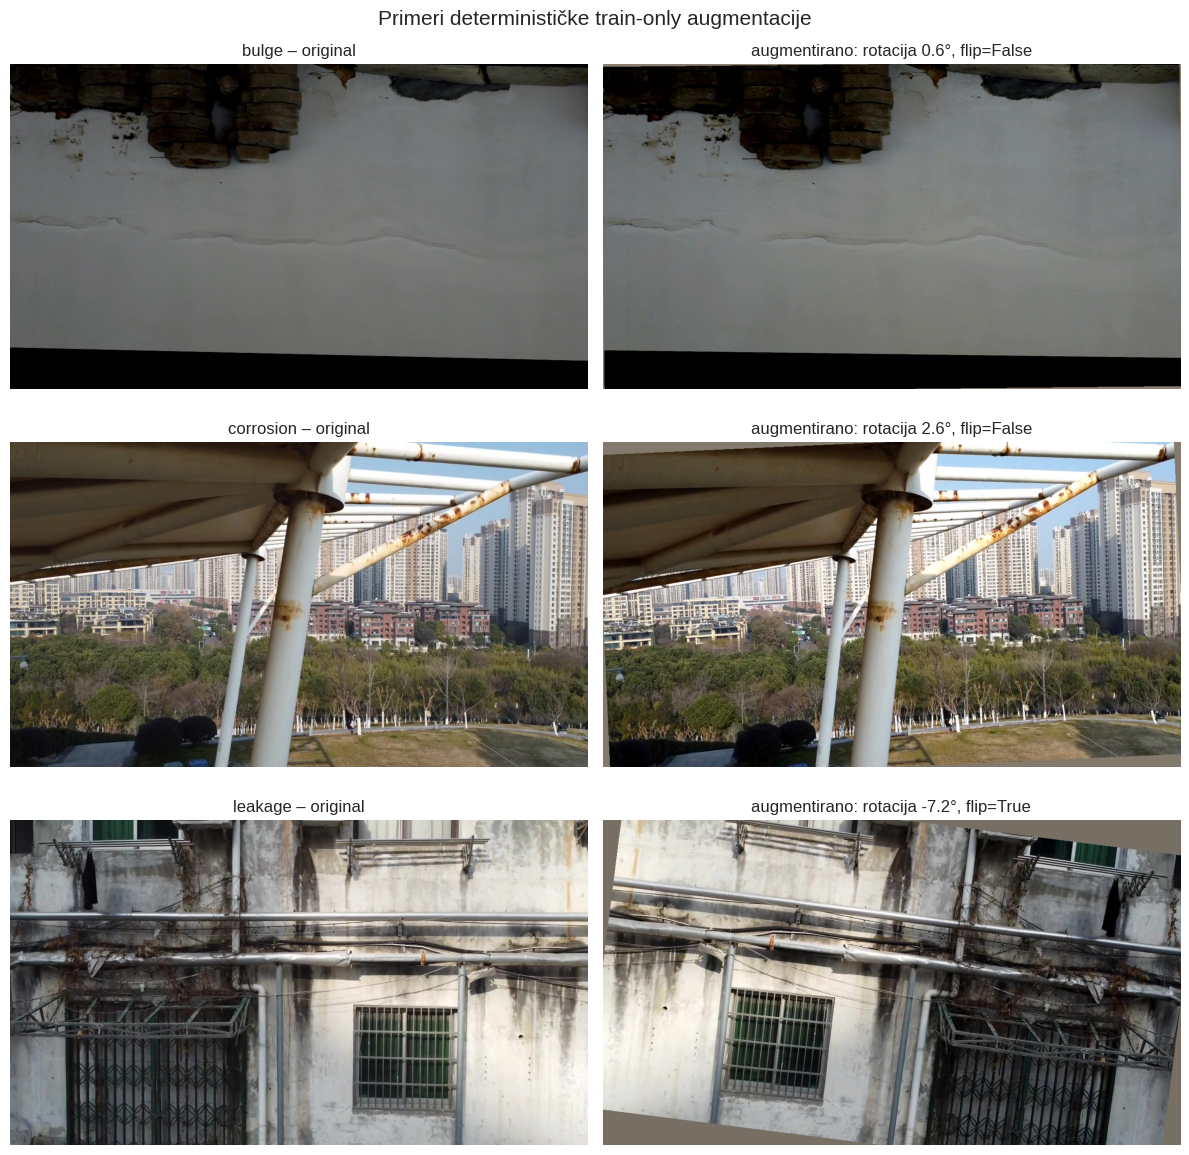

In [3]:
augmented_examples = (
    augmentation_metadata.loc[augmentation_metadata["is_augmented"]]
    .groupby("target_class", group_keys=False)
    .head(1)
    .set_index("target_class")
    .reindex(["bulge", "corrosion", "leakage"])
    .reset_index()
)

figure, axes = plt.subplots(3, 2, figsize=(12, 12))

for row_index, row in augmented_examples.iterrows():
    with Image.open(row["image_path"]) as source:
        source = source.convert("RGB")
        transformed = augment_image(source.copy(), row)

    axes[row_index, 0].imshow(source)
    axes[row_index, 0].set_title(f"{row['target_class']} – original")
    axes[row_index, 1].imshow(transformed)
    axes[row_index, 1].set_title(
        f"augmentirano: rotacija {row['rotation_degrees']:.1f}°, "
        f"flip={bool(row['horizontal_flip'])}"
    )

    for axis in axes[row_index]:
        axis.axis("off")

figure.suptitle("Primeri determinističke train-only augmentacije", fontsize=15)
figure.tight_layout()
plt.show()

## 3. Zaštita od data leakage-a

Augmentacija je izvedena tek nakon grupisanog train/validation/test razdvajanja. Svaki novi prikaz nasleđuje `source_image_id`, klasu, split i `visual_group` izvorne slike. Time augmentirana verzija ne može preći u validation ili test skup.

Pored toga, spojeni feature fajl koristi originalne feature vektore za sve neaugmentirane slike, a novodobijene vektore samo za augmentirane prikaze. Zbog toga su validation i test feature-i bit-po-bit isti kao u Eksperimentu 2.

In [4]:
leakage_checks = pd.Series(
    augmentation_report["leakage_checks"]
).rename({
    "augmentations_only_in_train": "Augmentacije postoje samo u train skupu",
    "original_splits_unchanged": "Originalni splitovi nisu promenjeni",
    "one_split_per_visual_group": "Svaka visual_group pripada jednom splitu",
    "one_split_per_source_image": "Svaka izvorna slika pripada jednom splitu",
}).to_frame("Provera uspešna")

display(leakage_checks)

assert leakage_checks["Provera uspešna"].all()
assert not augmentation_metadata.loc[
    augmentation_metadata["is_augmented"], "split"
].ne("train").any()
assert augmentation_metadata.groupby("visual_group")["split"].nunique().max() == 1
assert augmentation_metadata.groupby("source_image_id")["split"].nunique().max() == 1

print("Sve kontrole protiv data leakage-a su uspešne.")

,Provera uspešna
Augmentacije postoje samo u train skupu,True
Originalni splitovi nisu promenjeni,True
Svaka visual_group pripada jednom splitu,True
Svaka izvorna slika pripada jednom splitu,True


Sve kontrole protiv data leakage-a su uspešne.


## 4. Izbor modela na validation skupu

Zadržani su Inception-ResNet-v2 feature-i i XGBoost iz osnovnog eksperimenta. Za augmentirani trening skup ponovljeno je istih osam konfiguracija (`max_depth`, `learning_rate` i balansirane težine). Model je biran prema validation macro F1 vrednosti.

,dataset_variant,težine,max_depth,learning_rate,n_estimators,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Augmentirani train,ne,8,0.1000,143,0.9681,0.9767,0.9769,0.9685
1,Augmentirani train,da,8,0.1000,109,0.9648,0.9722,0.9738,0.9653
2,Originalni train,da,4,0.1000,239,0.9648,0.9722,0.9737,0.9653
3,Originalni train,ne,8,0.0300,604,0.9530,0.9568,0.9620,0.9537


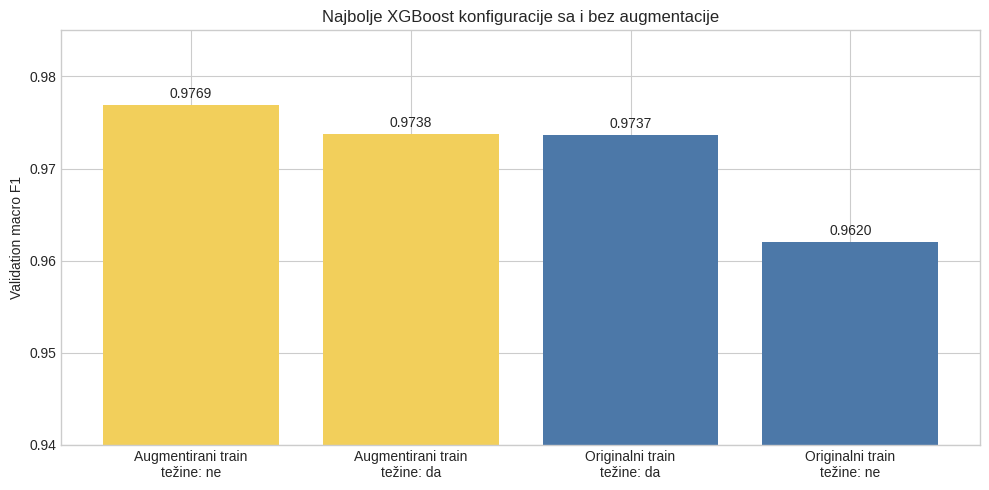

In [5]:
validation_display = validation_comparison.copy()
validation_display["težine"] = validation_display["balanced_weights"].map(
    {True: "da", False: "ne"}
)
validation_display = validation_display[
    [
        "dataset_variant", "težine", "max_depth", "learning_rate",
        "n_estimators", "accuracy", "balanced_accuracy", "macro_f1",
        "weighted_f1",
    ]
]
display(validation_display)

labels = [
    f"{row.dataset_variant}\ntežine: {'da' if row.balanced_weights else 'ne'}"
    for row in validation_comparison.itertuples(index=False)
]
colors = [
    "#F2CF5B" if row.dataset_variant == "Augmentirani train" else "#4C78A8"
    for row in validation_comparison.itertuples(index=False)
]

figure, axis = plt.subplots(figsize=(10, 5))
bars = axis.bar(labels, validation_comparison["macro_f1"], color=colors)
axis.set_ylim(0.94, 0.985)
axis.set_ylabel("Validation macro F1")
axis.set_title("Najbolje XGBoost konfiguracije sa i bez augmentacije")
axis.bar_label(bars, fmt="%.4f", padding=3)
plt.tight_layout()
plt.show()

In [6]:
baseline_validation = validation_result["baseline_validation_macro_f1"]
augmented_validation = validation_result["best_augmented_validation_macro_f1"]
validation_change = validation_result["macro_f1_difference"]
best_parameters = validation_result["best_parameters"]

print(f"Originalni validation macro F1: {baseline_validation:.4f}")
print(f"Augmentirani validation macro F1: {augmented_validation:.4f}")
print(f"Promena: {validation_change:+.4f}")
print("\nIzabrani hiperparametri:")
display(pd.Series(best_parameters).to_frame("Vrednost"))

Originalni validation macro F1: 0.9737
Augmentirani validation macro F1: 0.9769
Promena: +0.0032

Izabrani hiperparametri:


,Vrednost
max_depth,8
learning_rate,0.1000
balanced_weights,False
n_estimators,143
subsample,0.8000
colsample_bytree,0.8000
reg_alpha,0.0000
reg_lambda,1.0000


Augmentirani skup je povećao validation macro F1 sa **0,9737** na **0,9769**. Najbolji model koristio je dubinu 8, learning rate 0,1 i 143 stabla, bez dodatnih težina klasa. Ovaj rezultat je bio unapred definisan uslov da se model pusti na test.

## 5. Finalna evaluacija na test skupu

Izabrani model je treniran nad augmentiranim train skupom i originalnim validation primerima, a zatim evaluiran nad potpuno neizmenjenim test skupom od 1.215 slika.

,Accuracy,Balanced accuracy,Macro F1,Weighted F1
experiment,,,,
Eksperiment 2,0.7292,0.7921,0.7823,0.7350
Eksperiment 2B – augmentacija,0.6955,0.7701,0.7409,0.6944


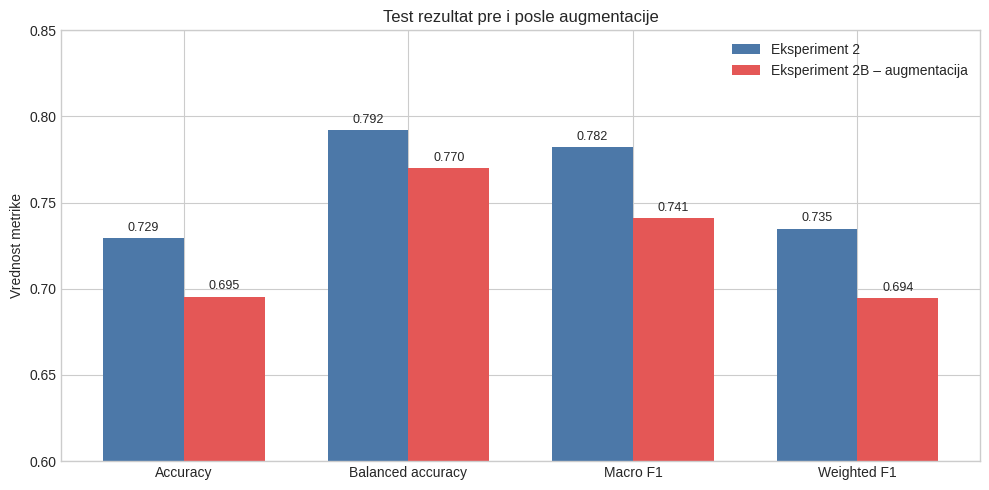

In [7]:
metric_columns = {
    "test_accuracy": "Accuracy",
    "test_balanced_accuracy": "Balanced accuracy",
    "test_macro_f1": "Macro F1",
    "test_weighted_f1": "Weighted F1",
}

test_metrics_table = (
    test_comparison
    .set_index("experiment")
    [list(metric_columns)]
    .rename(columns=metric_columns)
)
display(test_metrics_table)

metric_names = list(metric_columns.values())
x = np.arange(len(metric_names))
width = 0.36

figure, axis = plt.subplots(figsize=(10, 5))
for index, row in test_comparison.iterrows():
    values = [row[column] for column in metric_columns]
    offset = (index - 0.5) * width
    bars = axis.bar(
        x + offset,
        values,
        width,
        label=row["experiment"],
        color=COLORS[row["experiment"]],
    )
    axis.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

axis.set_xticks(x, metric_names)
axis.set_ylim(0.60, 0.85)
axis.set_ylabel("Vrednost metrike")
axis.set_title("Test rezultat pre i posle augmentacije")
axis.legend(frameon=False)
figure.tight_layout()
plt.show()

In [8]:
baseline_row = test_comparison.iloc[0]
augmented_row = test_comparison.iloc[1]

metric_change = pd.DataFrame({
    "Metrika": ["Accuracy", "Balanced accuracy", "Macro F1", "Weighted F1"],
    "Promena": [
        augmented_row["test_accuracy"] - baseline_row["test_accuracy"],
        augmented_row["test_balanced_accuracy"] - baseline_row["test_balanced_accuracy"],
        augmented_row["test_macro_f1"] - baseline_row["test_macro_f1"],
        augmented_row["test_weighted_f1"] - baseline_row["test_weighted_f1"],
    ],
})
display(metric_change)

print(
    "Test macro F1 promena: "
    f"{metric_change.loc[metric_change['Metrika'].eq('Macro F1'), 'Promena'].iloc[0]:+.4f}"
)

,Metrika,Promena
0,Accuracy,-0.0337
1,Balanced accuracy,-0.0221
2,Macro F1,-0.0414
3,Weighted F1,-0.0406


Test macro F1 promena: -0.0414


Uprkos malom rastu na validation skupu, test macro F1 je opao sa **0,7823** na **0,7409**. Accuracy je opao za približno 3,4 procentna poena, a macro F1 za približno 4,1 procentni poen. Augmentacija zato nije poboljšala ukupnu generalizaciju.

## 6. Promena rezultata po klasama

,baseline_f1,augmented_f1,change
class_name,,,
abscission,0.7105,0.6130,-0.0975
bulge,1.0000,1.0000,0.0000
corrosion,0.9818,0.8475,-0.1343
crack,0.6931,0.7070,0.0140
leakage,0.5261,0.5368,0.0107


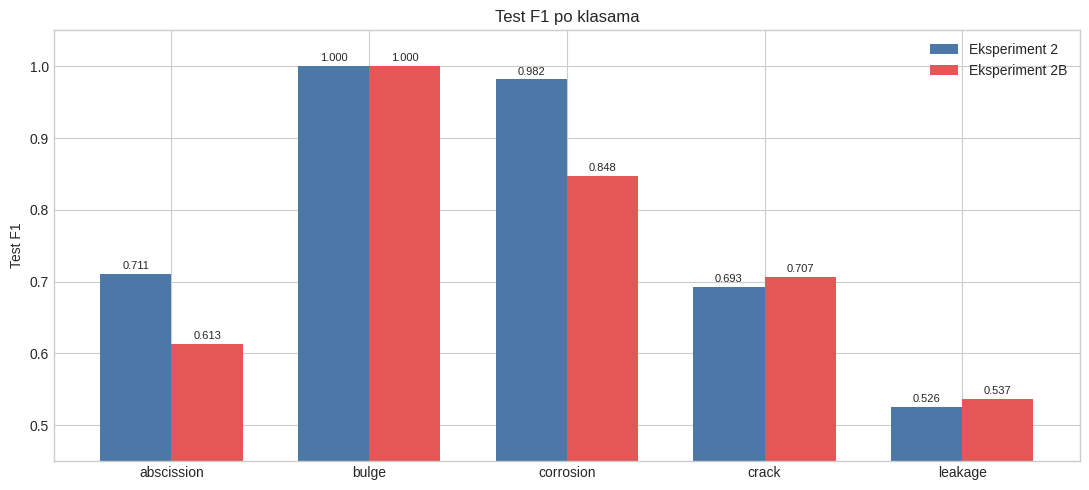

In [9]:
class_f1 = class_f1_comparison.set_index("class_name").reindex(CLASS_ORDER)
display(class_f1)

x = np.arange(len(class_f1))
width = 0.36
figure, axis = plt.subplots(figsize=(11, 5))

baseline_bars = axis.bar(
    x - width / 2,
    class_f1["baseline_f1"],
    width,
    label="Eksperiment 2",
    color="#4C78A8",
)
augmented_bars = axis.bar(
    x + width / 2,
    class_f1["augmented_f1"],
    width,
    label="Eksperiment 2B",
    color="#E45756",
)

axis.set_xticks(x, class_f1.index)
axis.set_ylim(0.45, 1.05)
axis.set_ylabel("Test F1")
axis.set_title("Test F1 po klasama")
axis.legend(frameon=False)
axis.bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
axis.bar_label(augmented_bars, fmt="%.3f", padding=2, fontsize=8)
figure.tight_layout()
plt.show()

Efekat nije bio jednak za sve klase:

- `leakage` je porastao sa 0,5261 na 0,5368;
- `crack` je porastao sa 0,6931 na 0,7070;
- `bulge` je ostao na 1,0000;
- `abscission` je opao sa 0,7105 na 0,6130;
- `corrosion` je opao sa 0,9818 na 0,8475.

Augmentacija je blago pomogla dvema problematičnim klasama, ali je proizvela više pogrešnih pozitivnih predikcija za druge klase. Dobitak nije bio dovoljan da nadoknadi gubitke kod `abscission` i `corrosion`.

## 7. Matrica konfuzije i analiza grešaka

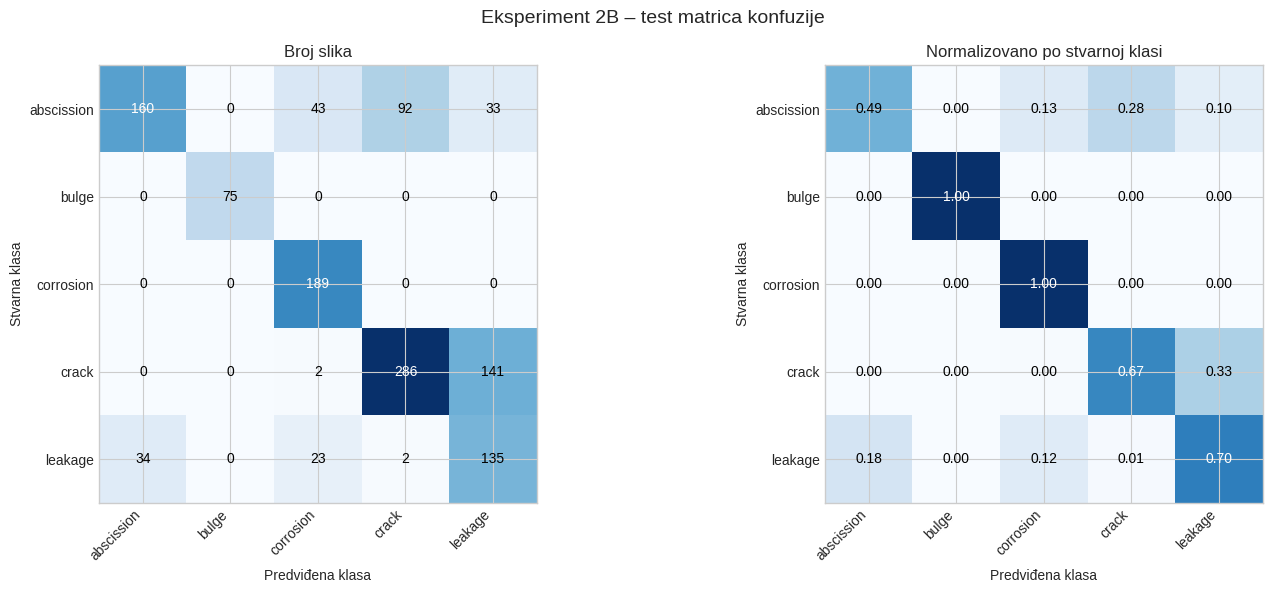

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(15, 6))

for axis, matrix, title, fmt in [
    (axes[0], confusion_counts, "Broj slika", "d"),
    (axes[1], confusion_normalized, "Normalizovano po stvarnoj klasi", ".2f"),
]:
    values = matrix.to_numpy()
    image = axis.imshow(values, cmap="Blues", vmin=0)
    axis.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha="right")
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set_xlabel("Predviđena klasa")
    axis.set_ylabel("Stvarna klasa")
    axis.set_title(title)

    threshold = values.max() / 2
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            label = format(int(value), fmt) if fmt == "d" else format(value, fmt)
            axis.text(
                column,
                row,
                label,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )

figure.suptitle("Eksperiment 2B – test matrica konfuzije", fontsize=14)
figure.tight_layout()
plt.show()

In [11]:
errors = []
for true_class in confusion_counts.index:
    for predicted_class in confusion_counts.columns:
        if true_class != predicted_class:
            errors.append({
                "Stvarna klasa": true_class,
                "Predviđena klasa": predicted_class,
                "Broj slika": int(confusion_counts.loc[true_class, predicted_class]),
            })

error_table = (
    pd.DataFrame(errors)
    .sort_values("Broj slika", ascending=False)
    .reset_index(drop=True)
)

display(error_table.head(10))

,Stvarna klasa,Predviđena klasa,Broj slika
0,crack,leakage,141
1,abscission,crack,92
2,abscission,corrosion,43
3,leakage,abscission,34
4,abscission,leakage,33
5,leakage,corrosion,23
6,leakage,crack,2
7,crack,corrosion,2
8,abscission,bulge,0
9,bulge,abscission,0


Najizraženije greške ostaju povezane sa vizuelno sličnim pojavama. Model je 141 `crack` sliku klasifikovao kao `leakage`, dok je 92 `abscission` slike klasifikovao kao `crack`. Kod klase `corrosion` recall je ostao 1,0, ali je precision opao jer je model veći broj slika drugih klasa označio kao koroziju.

## 8. Validation–test razlika

,validation_macro_f1,test_macro_f1,validation_test_gap
experiment,,,
Eksperiment 2,0.9737,0.7823,0.1914
Eksperiment 2B – augmentacija,0.9769,0.7409,0.2360


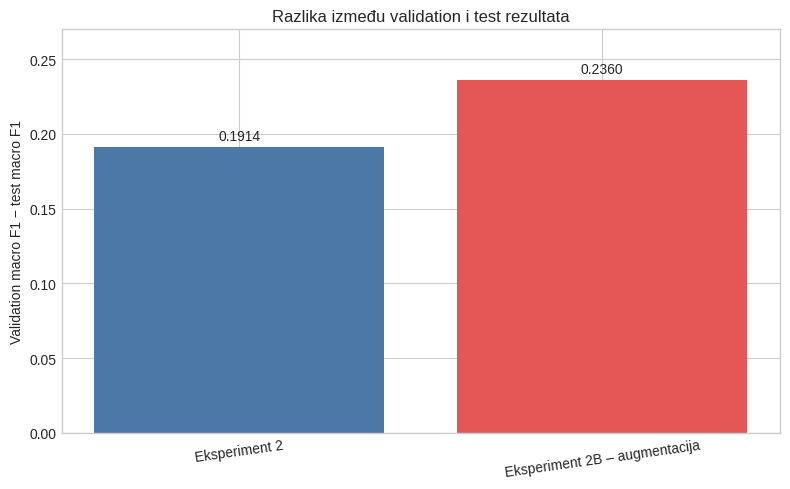

In [12]:
gap_table = test_comparison[
    ["experiment", "validation_macro_f1", "test_macro_f1", "validation_test_gap"]
].set_index("experiment")
display(gap_table)

figure, axis = plt.subplots(figsize=(8, 5))
bars = axis.bar(
    gap_table.index,
    gap_table["validation_test_gap"],
    color=[COLORS[name] for name in gap_table.index],
)
axis.set_ylabel("Validation macro F1 − test macro F1")
axis.set_title("Razlika između validation i test rezultata")
axis.bar_label(bars, fmt="%.4f", padding=3)
axis.set_ylim(0, 0.27)
plt.xticks(rotation=8)
plt.tight_layout()
plt.show()

Validation–test razlika se povećala sa **0,1914** na **0,2360**. To pokazuje da veštačko izjednačavanje broja trening primera nije rešilo razliku između distribucija validation i test skupa.

Moguća objašnjenja su:

1. transformacije povećavaju broj prikaza, ali ne uvode nove objekte, lokacije ni uslove snimanja;
2. više augmentiranih kopija može pojačati specifične osobine malog broja izvornih slika;
3. validation skup je i dalje optimističan u odnosu na test skup;
4. jedinstven skup transformacija nije podjednako odgovarao svim vrstama defekata.

Ovo su interpretacije rezultata, a ne dokazani pojedinačni uzroci.

## 9. Ograničenja eksperimenta

- Test skup je već korišćen u Eksperimentu 2, pa je Eksperiment 2B naknadna analiza.
- Ispitana je jedna kontrolisana strategija augmentacije i jedan prethodno izabrani model.
- Augmentacija ne stvara novu semantičku raznovrsnost jednaku prikupljanju novih fotografija.
- Mali validation dobitak od 0,0032 može zavisiti od konkretnog splita.
- Za pouzdaniju procenu trebalo bi koristiti grupisanu unakrsnu validaciju ili dodatni eksterni test skup.

Rezultat ne pokazuje da je svaka augmentacija neefikasna. Pokazuje da **ova konkretna strategija** nije poboljšala finalnu generalizaciju.

## 10. Zaključak i konačan izbor

Eksperiment 2B je uspešno ispitao profesorov predlog o augmentaciji manjinskih klasa uz očuvanu zaštitu od data leakage-a.

- Validation macro F1 porastao je sa **0,9737** na **0,9769**.
- Test macro F1 opao je sa **0,7823** na **0,7409**.
- Validation–test razlika povećala se sa **0,1914** na **0,2360**.
- `leakage` i `crack` ostvarili su mala poboljšanja, ali su `abscission` i `corrosion` značajno oslabili.

Zbog toga **Inception-ResNet-v2 + XGBoost iz osnovnog Eksperimenta 2 ostaje konačni multiclass model**, sa test macro F1 vrednošću 0,7823. Eksperiment 2B se čuva kao dokumentovana ablation analiza koja pokazuje da bolji validation rezultat ne mora značiti bolju generalizaciju na test skupu.